## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import pickle
import numpy as np
import pandas as pd

# utils
from utils.config import load_config
from utils.data import load_pkl, map_domains
from utils.metrics import *
from utils.viz import *

# tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# models
from sklearn.ensemble import RandomForestClassifier

## Data loading

In [3]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]
marisma_pkl = cfg["data"]["MARISMa_REDUCED_PKL"]

In [4]:
driams = load_pkl(driams_pkl)
marisma = load_pkl(marisma_pkl)

In [7]:
data, label, meta = driams["data"], driams["label"], pd.DataFrame.from_records(list(driams["meta"]))
data_marisma, label_marisma, meta_marisma = marisma["data"], marisma["label"], pd.DataFrame.from_records(list(marisma["meta"]))

In [8]:
meta_marisma = meta_marisma.copy()

meta_marisma.insert(
    loc=0,
    column="hospital",
    value="MARISMA"
)

In [6]:
# Apply normalization: scale each spectrum to [0, 1]
X_min = data.min(axis=1, keepdims=True)
X_max = data.max(axis=1, keepdims=True)
data_norm = (data - X_min) / (X_max - X_min + 1e-8)

In [9]:
# Apply normalization: scale each spectrum to [0, 1]
X_min_marisma = data_marisma.min(axis=1, keepdims=True)
X_max_marisma = data_marisma.max(axis=1, keepdims=True)
data_norm_marisma = (data_marisma - X_min_marisma) / (X_max_marisma - X_min_marisma + 1e-8)

In [10]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data_norm[idx],
        "label": label[idx],
        "meta": meta.iloc[idx]
    }

In [11]:
species, counts = np.unique(filtered_data["DRIAMS_A"]["label"], return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 2573
Enterococcus_Faecium: 1800
Escherichia_Coli: 7381
Klebsiella_Pneumoniae: 4083
Pseudomonas_Aeruginosa: 4908
Staphylococcus_Aureus: 7065


In [12]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataB, labelB, metaB = filtered_data["DRIAMS_B"]["data"], filtered_data["DRIAMS_B"]["label"], filtered_data["DRIAMS_B"]["meta"]
dataC, labelC, metaC = filtered_data["DRIAMS_C"]["data"], filtered_data["DRIAMS_C"]["label"], filtered_data["DRIAMS_C"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

## Original space (train on DRIAMS-A (all years), test on MARISMA (all years))

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    dataA,
    labelA,
    test_size=0.2,
    stratify=labelA,
    shuffle=True,
    random_state=42
)

### Train

In [24]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_final.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Test


===== Metrics =====
Domain: DRIAMS-A
Balanced Accuracy: 0.9982
F1 Macro: 0.9986
Recall Macro: 0.9982
Specificity Macro: 0.9997



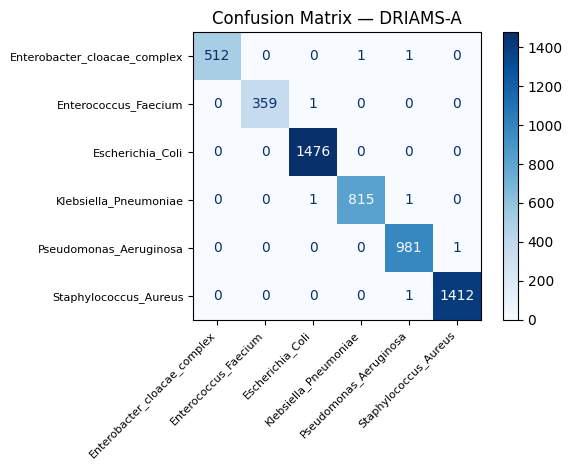


===== Metrics =====
Domain: DRIAMS-B
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



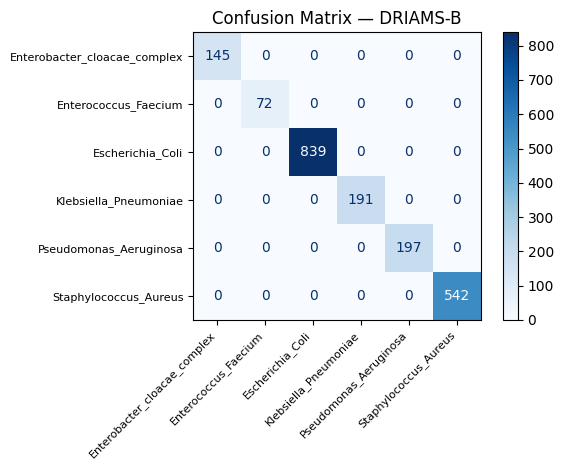


===== Metrics =====
Domain: DRIAMS-C
Balanced Accuracy: 0.9964
F1 Macro: 0.9971
Recall Macro: 0.9964
Specificity Macro: 0.9995



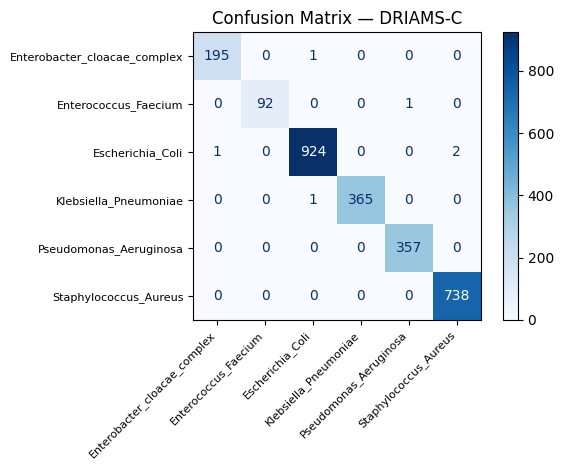


===== Metrics =====
Domain: DRIAMS-D
Balanced Accuracy: 0.9230
F1 Macro: 0.9117
Recall Macro: 0.9230
Specificity Macro: 0.9818



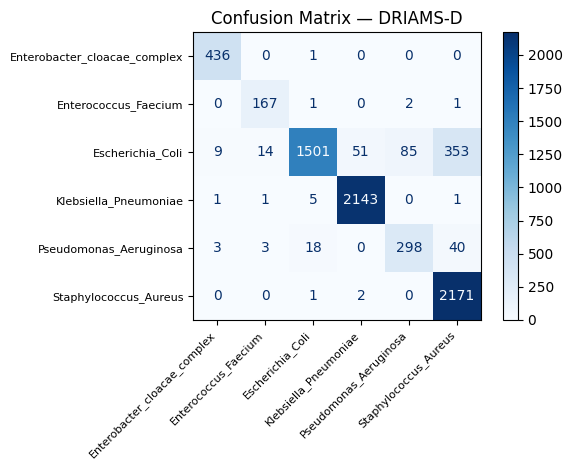


===== Metrics =====
Domain: MARISMA
Balanced Accuracy: 0.9902
F1 Macro: 0.9928
Recall Macro: 0.9902
Specificity Macro: 0.9993



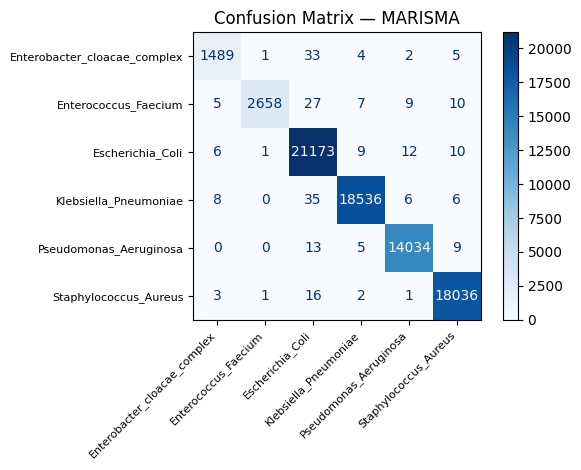

In [26]:
metricsA = metrics_report(X_test, y_test, rf_final, "DRIAMS-A")
metricsB = metrics_report(dataB, labelB, rf_final, "DRIAMS-B")
metricsC = metrics_report(dataC, labelC, rf_final, "DRIAMS-C")
metricsD = metrics_report(dataD, labelD, rf_final, "DRIAMS-D")
metrics_marisma = metrics_report(data_marisma, label_marisma, rf_final, "MARISMA")

print_metrics(metricsA)
print_metrics(metricsB)
print_metrics(metricsC)
print_metrics(metricsD)
print_metrics(metrics_marisma)

## After domain alignment

#### Utils

In [13]:
import torch
from models.deep.cVAEPrior import ConditionalVAE_Bernoulli_SpeciesPrior_Extended
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [14]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_with_domain(model, X, domain_ids, device, batch_size=256):
    """
    Encode data into latent space using domain-conditioned encoder.
    """
    model.eval()
    Z = []

    X_tensor = torch.tensor(X, dtype=torch.float32)
    domain_tensor = torch.tensor(domain_ids, dtype=torch.long)

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tensor, domain_tensor),
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for x, d in loader:
            x = x.to(device)
            d = d.to(device)

            c_domain = torch.nn.functional.one_hot(
                d, num_classes=model.cond_dim
            ).float()

            mu, _ = model.encoder(x, c_domain)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

def find_best_rf(Z_train, y_train_z):
    param_grid = {
        "n_estimators": [200, 400, 800],
        "max_depth": [None, 20, 40],
    }

    rf = RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    )

    grid = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1,
        verbose=1,
        refit=True  
    )
    grid.fit(Z_train, y_train_z)

    print("Best params:", grid.best_params_)
    print("Best CV balanced_acc:", grid.best_score_)

    # Evaluar en test de D
    rf_best = grid.best_estimator_
    return rf_best

#### Load and train

In [16]:
meta_all = pd.concat([metaA, metaD, meta_marisma], ignore_index=True)
data_all = np.vstack([dataA, dataD, data_norm_marisma])
label_all = np.concatenate([labelA, labelD, label_marisma])

domain_ids = map_domains(meta_all)

# Forzar MARISMA → dominio 0 (por ejemplo A)
domain_ids[meta_all["hospital"] == "MARISMA"] = 0

In [17]:
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/results/cvae_species_prior/20251231_134427/model.pth"

backbone = ConditionalVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=dataA.shape[1],
    latent_dim=64,
    cond_dim=2,                     
    n_species=len(np.unique(labelA))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
Z_all = encode_with_domain(
    model=vae,
    X=data_all,
    domain_ids=domain_ids,
    device=device
)

print("Latent space shape:", Z_all.shape)


# Get latent representations
mask_A = meta_all["hospital"] == "DRIAMS_A"
mask_D = meta_all["hospital"] == "DRIAMS_D"
mask_M = (meta_all["hospital"] == "MARISMA") & (meta_all["year"] == '2018')

Z_A = Z_all[mask_A]
Z_D = Z_all[mask_D]
Z_M = Z_all[mask_M]

y_A = label_all[mask_A]
y_D = label_all[mask_D]
y_M = label_all[mask_M]

print(f"Z_A: {Z_A.shape}")
print(f"Z_D: {Z_D.shape}")
print(f"Z_M: {Z_M.shape}")

# Define train and test
Z_train, y_train_z = Z_A, labelA
Z_test_D = Z_D
y_test_D = y_D

Z_test_M = Z_M
y_test_M = y_M

Latent space shape: (111290, 64)
Z_A: (27810, 64)
Z_D: (7308, 64)
Z_M: (5771, 64)


In [22]:
# Find best RF
rf_best = find_best_rf(Z_train, y_train_z)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


Process LokyProcess-41:
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/export/usuarios01/agnavarr/MALDIAlign/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 505, in _process_worker
    _process_reference_size = _get_memory_usage(pid, force_gc=True)
  File "/export/usuarios01/agnavarr/MALDIAlign/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 110, in _get_memory_usage
    gc.collect()
    ~~~~~~~~~~^^
KeyboardInterrupt


KeyboardInterrupt: 

In [31]:
rf_best = RandomForestClassifier(
    n_estimators=300,          # suficiente
    max_depth=30,              # controla overfitting
    min_samples_leaf=5,        # MUY importante con 37k
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=123
)

rf_best.fit(Z_train, y_train_z)

,n_estimators,300
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Test


===== Metrics =====
Domain: A (train)
Balanced Accuracy: 0.9996
F1 Macro: 0.9996
Recall Macro: 0.9996
Specificity Macro: 0.9999



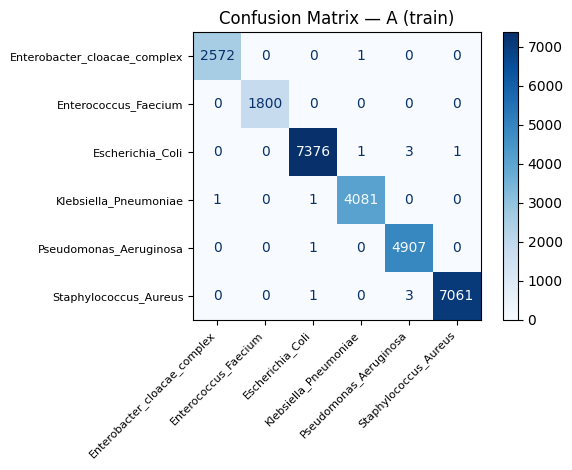


===== Metrics =====
Domain: D (test)
Balanced Accuracy: 0.9807
F1 Macro: 0.9838
Recall Macro: 0.9807
Specificity Macro: 0.9979



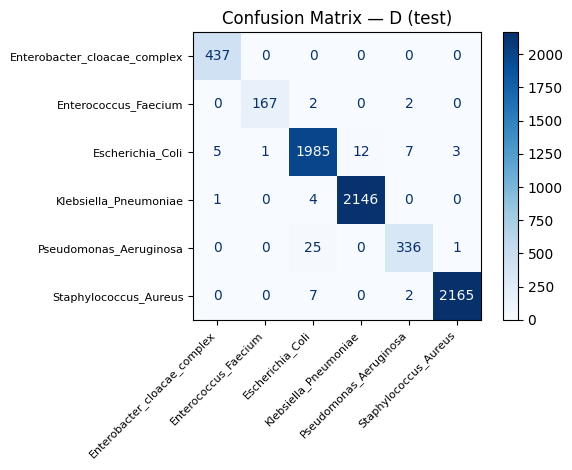


===== Metrics =====
Domain: MARISMA (test)
Balanced Accuracy: 0.9926
F1 Macro: 0.9954
Recall Macro: 0.9926
Specificity Macro: 0.9993



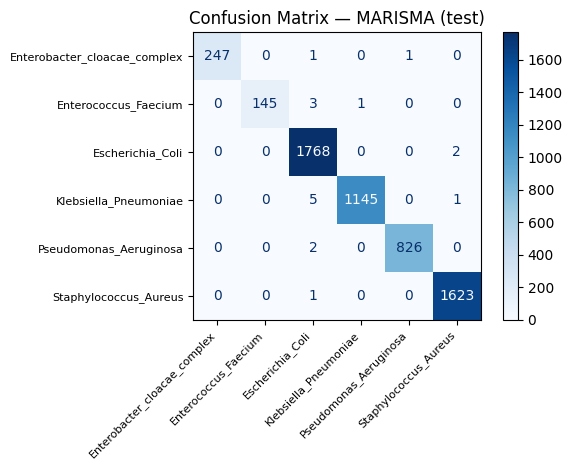

In [32]:
metrics_A = metrics_report(Z_train, y_train_z, rf_best, "A (train)")
metrics_D = metrics_report(Z_test_D, y_test_D, rf_best, "D (test)")
metrics_M = metrics_report(Z_test_M, y_test_M, rf_best, "MARISMA (test)")

print_metrics(metrics_A)
print_metrics(metrics_D)
print_metrics(metrics_M)